In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

In [4]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_dataset-testing-master.csv to customer_churn_dataset-testing-master.csv


In [5]:
df = pd.read_csv("customer_churn_dataset-testing-master.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [6]:

print(df.shape)

print(df.columns)


(64374, 12)
Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')


In [7]:

print(df.isnull().sum())

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [8]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [9]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)



print(pd.Series(y_train_smote).value_counts())


Churn
0    27105
1    24394
Name: count, dtype: int64
Churn
0    27105
1    27105
Name: count, dtype: int64


In [13]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_smote, y_train_smote)

y_pred_lr = lr_model.predict(X_test_scaled)

print("\n===== Logistic Regression =====")

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


===== Logistic Regression =====
Accuracy: 0.8605825242718447

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      6776
           1       0.85      0.86      0.85      6099

    accuracy                           0.86     12875
   macro avg       0.86      0.86      0.86     12875
weighted avg       0.86      0.86      0.86     12875



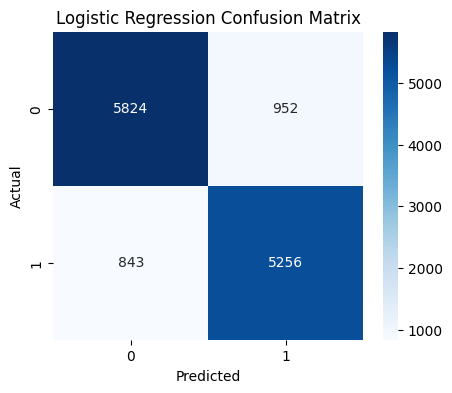

In [14]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train_smote, y_train_smote)

y_pred_dt = dt_model.predict(X_test_scaled)

print("\n===== Decision Tree =====")
print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))



===== Decision Tree =====
Accuracy: 0.9579029126213592

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      6776
           1       0.96      0.95      0.96      6099

    accuracy                           0.96     12875
   macro avg       0.96      0.96      0.96     12875
weighted avg       0.96      0.96      0.96     12875



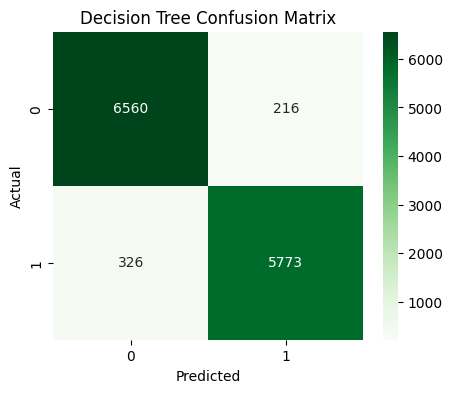

In [16]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:")
print(importance.head(10))


Top Important Features:
             Feature  Importance
0         CustomerID    0.498538
6      Payment Delay    0.203930
5      Support Calls    0.110633
3             Tenure    0.103836
2             Gender    0.045694
1                Age    0.020291
4    Usage Frequency    0.017079
7  Subscription Type    0.000000
8    Contract Length    0.000000
9        Total Spend    0.000000


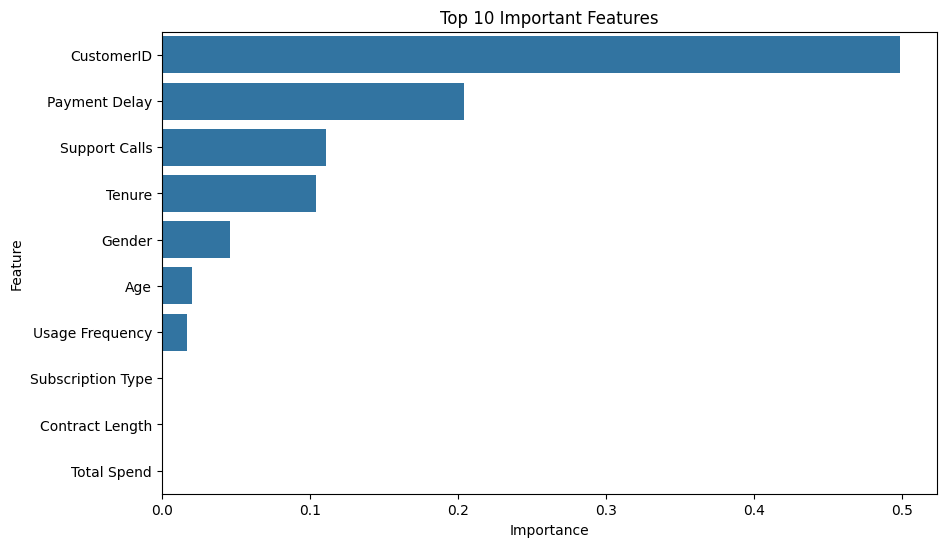

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [19]:
target_column = "Churn"

X = df.drop(target_column, axis=1)
y = df[target_column]


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
print("\nBefore SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Before SMOTE:
Churn
0    27105
1    24394
Name: count, dtype: int64

After SMOTE:
Churn
0    27105
1    27105
Name: count, dtype: int64


In [28]:
if lr_accuracy > dt_accuracy:
    best_model = lr_model
    best_model_name = "Logistic Regression"
    best_accuracy = lr_accuracy
else:
    best_model = dt_model
    best_model_name = "Decision Tree"
    best_accuracy = dt_accuracy

print("\n=================================")
print("Best Model :", best_model_name)
print("Best Accuracy :", best_accuracy)



Best Model : Decision Tree
Best Accuracy : 0.9579029126213592


In [32]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:")
print(importance.head(10))

plt.figure(figsize=(10,6))



Top Important Features:
             Feature  Importance
0         CustomerID    0.498538
6      Payment Delay    0.203930
5      Support Calls    0.110633
3             Tenure    0.103836
2             Gender    0.045694
1                Age    0.020291
4    Usage Frequency    0.017079
7  Subscription Type    0.000000
8    Contract Length    0.000000
9        Total Spend    0.000000


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

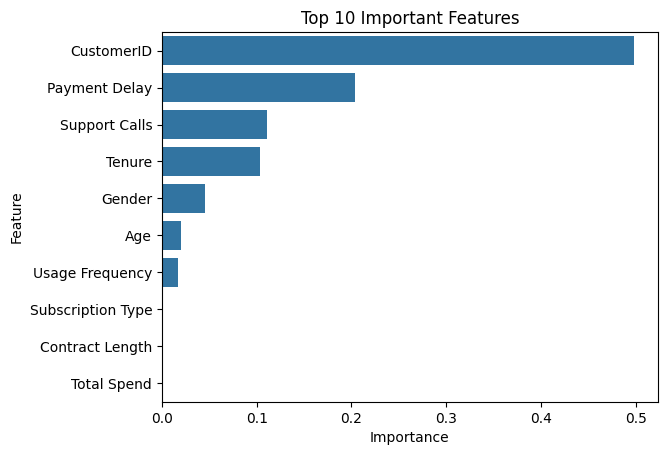

In [31]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [33]:
print("\nFeature Columns:")
print(X.columns)


Feature Columns:
Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction'],
      dtype='object')
